# 4.3.3. Влияние параметров dt, n_iter, n_runs

В этой тетрадке исследуется чувствительность bSB и dSB к основным численным параметрам:

- `dt` - шаг интегрирования;
- `n_iter` - число итераций SB-динамики;
- `n_runs` - число независимых запусков.

В отличие от раздела 4.3.2, здесь цель состоит не в сравнении алгоритмов на максимальном числе размерностей, а в анализе устойчивости результатов при изменении параметров.

Сначала фиксируем `n_iter` и `n_runs` и исследуем влияние `dt`.

In [1]:
import numpy as np
import pandas as pd
import itertools
import time
import matplotlib.pyplot as plt

import sys
sys.path.append('курсовая_2')
from SB_modules import BSB, DSB

In [2]:
def ising_energy(s, J, h=None):
    """
    E(s) = - sum_{i<j} J_ij s_i s_j - sum_i h_i s_i
    """
    s = np.asarray(s, dtype=int).reshape(-1)
    J = np.asarray(J, dtype=float)

    if h is None:
        h = np.zeros_like(s, dtype=float)
    else:
        h = np.asarray(h, dtype=float).reshape(-1)

    pair_term = 0.0
    N = len(s)

    for i in range(N):
        for j in range(i + 1, N):
            pair_term += J[i, j] * s[i] * s[j]

    field_term = np.dot(h, s)

    return float(-pair_term - field_term)

In [3]:
def brute_force_ising_chunked(J, h=None, chunk_size=200_000):
    """
    Ускоренный полный перебор всех 2^N конфигураций.

    Энергия:
        E(s) = -1/2 s^T J s - h^T s

    Подходит для N примерно до 20-22.
    """
    J = np.asarray(J, dtype=float)
    N = J.shape[0]

    if h is None:
        h = np.zeros(N, dtype=float)
    else:
        h = np.asarray(h, dtype=float).reshape(-1)

    total = 1 << N
    best_energy = np.inf
    best_states_count = 0

    powers = (1 << np.arange(N, dtype=np.uint64))

    for start in range(0, total, chunk_size):
        end = min(start + chunk_size, total)

        nums = np.arange(start, end, dtype=np.uint64)[:, None]
        bits = ((nums & powers) > 0).astype(np.int8)

        S = 2 * bits - 1
        S = S.astype(float)

        pair_energy = -0.5 * np.sum((S @ J) * S, axis=1)
        field_energy = -(S @ h)
        energies = pair_energy + field_energy

        local_min = energies.min()

        if local_min < best_energy - 1e-12:
            best_energy = float(local_min)
            best_states_count = int(np.sum(np.isclose(energies, best_energy)))

        elif np.isclose(local_min, best_energy):
            best_states_count += int(np.sum(np.isclose(energies, best_energy)))

    return best_energy, best_states_count

In [4]:
def generate_random_ising_instance(N, seed=None, p_edge=1.0, with_field=False):
    """
    Генерирует случайную Ising-модель.

    J_ij in {-1, +1} с вероятностью p_edge.
    h_i = 0, если with_field=False.
    """
    rng = np.random.default_rng(seed)

    J = np.zeros((N, N), dtype=float)

    for i in range(N):
        for j in range(i + 1, N):
            if rng.random() <= p_edge:
                val = rng.choice([-1.0, 1.0])
                J[i, j] = val
                J[j, i] = val

    if with_field:
        h = rng.uniform(-0.5, 0.5, size=N)
    else:
        h = np.zeros(N, dtype=float)

    return J, h

In [5]:
def run_sb_many(
    J,
    h=None,
    variant="BSB",
    n_runs=50,
    n_iter=1000,
    dt=0.05,
    seed=42,
):
    J = np.asarray(J, dtype=float)
    N = J.shape[0]

    if h is None:
        h = np.zeros((N, 1), dtype=float)
    else:
        h = np.asarray(h, dtype=float).reshape(N, 1)

    rows = []

    for r in range(n_runs):
        run_seed = seed + r

        if variant.upper() == "BSB":
            solver = BSB(J, h=h, n_iter=n_iter, dt=dt, seed=run_seed)
        elif variant.upper() == "DSB":
            solver = DSB(J, h=h, n_iter=n_iter, dt=dt, seed=run_seed)
        else:
            raise ValueError("variant must be 'BSB' or 'DSB'")

        start = time.perf_counter()
        solver.run(record_trajectory=False)
        elapsed = time.perf_counter() - start

        x_final = solver.x.reshape(-1)
        s_final = np.where(x_final >= 0, 1, -1)

        E = ising_energy(s_final, J, h.reshape(-1))

        rows.append({
            "variant": variant.upper(),
            "run": r,
            "seed": run_seed,
            "energy": E,
            "state": tuple(s_final.tolist()),
            "runtime_sec": elapsed,
        })

    return pd.DataFrame(rows)

In [6]:
BENCHMARK_N = 16
N_INSTANCES = 5
BASE_SEED = 2026

benchmark_instances = []

for instance_id in range(N_INSTANCES):
    seed = BASE_SEED + instance_id

    J, h = generate_random_ising_instance(
        N=BENCHMARK_N,
        seed=seed,
        p_edge=1.0,
        with_field=False,
    )

    E_exact, n_exact_states = brute_force_ising_chunked(J, h)

    benchmark_instances.append({
        "instance_id": instance_id,
        "J": J,
        "h": h,
        "E_exact": E_exact,
        "n_exact_states": n_exact_states,
    })

pd.DataFrame([
    {
        "instance_id": item["instance_id"],
        "N": BENCHMARK_N,
        "E_exact": item["E_exact"],
        "n_exact_states": item["n_exact_states"],
    }
    for item in benchmark_instances
])

,instance_id,N,E_exact,n_exact_states
0,0,16,-40.0,8
1,1,16,-38.0,4
2,2,16,-40.0,4
3,3,16,-40.0,2
4,4,16,-38.0,2


# Влияние шага интегрирования `dt`

In [7]:
DT_VALUES = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5, 0.65, 1.0]

FIXED_N_ITER = 1000
FIXED_N_RUNS = 50

SWEEP_SEED = 777

In [8]:
dt_sweep_rows = []

for dt in DT_VALUES:
    print(f"dt = {dt}")

    for item in benchmark_instances:
        instance_id = item["instance_id"]
        J = item["J"]
        h = item["h"]
        E_exact = item["E_exact"]

        for variant in ["BSB", "DSB"]:
            df = run_sb_many(
                J=J,
                h=h,
                variant=variant,
                n_runs=FIXED_N_RUNS,
                n_iter=FIXED_N_ITER,
                dt=dt,
                seed=SWEEP_SEED + 10_000 * instance_id,
            )

            gaps = df["energy"].values - E_exact

            dt_sweep_rows.append({
                "N": BENCHMARK_N,
                "instance_id": instance_id,
                "variant": variant,
                "dt": dt,
                "n_iter": FIXED_N_ITER,
                "n_runs": FIXED_N_RUNS,
                "E_exact": E_exact,
                "E_best": df["energy"].min(),
                "success_rate": np.mean(np.isclose(df["energy"], E_exact)),
                "mean_gap": np.mean(gaps),
                "median_gap": np.median(gaps),
                "best_gap": np.min(gaps),
                "max_gap": np.max(gaps),
                "mean_runtime_sec": df["runtime_sec"].mean(),
            })

results_dt_sweep_raw = pd.DataFrame(dt_sweep_rows)

results_dt_sweep_raw.head()

dt = 0.01
dt = 0.02
dt = 0.05
dt = 0.1
dt = 0.2
dt = 0.5
dt = 0.65
dt = 1.0


,N,instance_id,variant,dt,n_iter,n_runs,E_exact,E_best,success_rate,mean_gap,median_gap,best_gap,max_gap,mean_runtime_sec
0,16,0,BSB,0.01,1000,50,-40.0,-40.0,0.46,2.08,2.0,0.0,14.0,0.029244
1,16,0,DSB,0.01,1000,50,-40.0,-40.0,0.40,2.28,2.0,0.0,8.0,0.029604
2,16,1,BSB,0.01,1000,50,-38.0,-38.0,0.14,5.68,5.0,0.0,20.0,0.028571
3,16,1,DSB,0.01,1000,50,-38.0,-38.0,0.22,4.00,2.0,0.0,16.0,0.029376
4,16,2,BSB,0.01,1000,50,-40.0,-40.0,0.08,6.00,4.0,0.0,26.0,0.028412


In [9]:
summary_dt_sweep = (
    results_dt_sweep_raw
    .groupby(["dt", "variant"], as_index=False)
    .agg(
        mean_success_rate=("success_rate", "mean"),
        median_success_rate=("success_rate", "median"),
        mean_gap=("mean_gap", "mean"),
        median_gap=("median_gap", "mean"),
        mean_best_gap=("best_gap", "mean"),
        mean_runtime_sec=("mean_runtime_sec", "mean"),
        n_instances=("instance_id", "nunique"),
    )
)

summary_dt_sweep["mean_runtime_ms"] = (
    1000 * summary_dt_sweep["mean_runtime_sec"]
)

summary_dt_sweep = summary_dt_sweep.drop(columns=["mean_runtime_sec"])

summary_dt_sweep

,dt,variant,mean_success_rate,median_success_rate,mean_gap,median_gap,mean_best_gap,n_instances,mean_runtime_ms
0,0.01,BSB,0.240,0.18,4.776,3.8,0.0,5,29.069802
1,0.01,DSB,0.328,0.34,3.224,2.8,0.0,5,29.722905
2,0.02,BSB,0.364,0.40,2.304,1.2,0.0,5,29.098367
3,0.02,DSB,0.480,0.50,2.048,1.0,0.0,5,29.875752
4,0.05,BSB,0.860,1.00,0.280,0.0,0.0,5,28.755686
5,0.05,DSB,0.700,0.64,0.832,0.8,0.0,5,29.759729
6,0.10,BSB,0.976,1.00,0.048,0.0,0.0,5,29.538569
7,0.10,DSB,0.812,0.80,0.560,0.0,0.0,5,30.317865
8,0.20,BSB,0.996,1.00,0.008,0.0,0.0,5,29.146994
9,0.20,DSB,0.896,0.92,0.256,0.0,0.0,5,30.159100


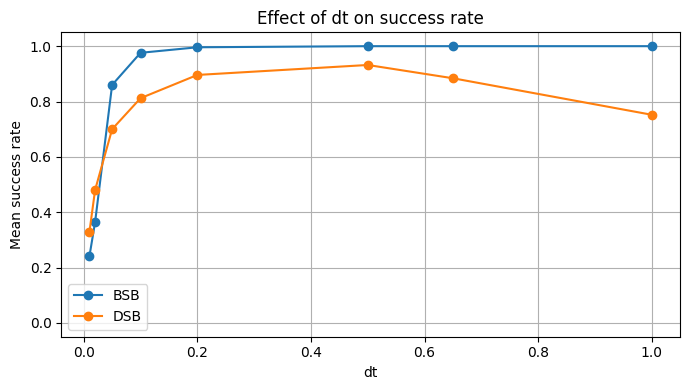

In [10]:
plt.figure(figsize=(7, 4))

for variant in ["BSB", "DSB"]:
    part = summary_dt_sweep[
        summary_dt_sweep["variant"] == variant
    ].sort_values("dt")

    plt.plot(
        part["dt"],
        part["mean_success_rate"],
        marker="o",
        label=variant,
    )

plt.xlabel("dt")
plt.ylabel("Mean success rate")
plt.title("Effect of dt on success rate")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("fig_04_03_03_dt_success_rate.png", dpi=300)
plt.show()

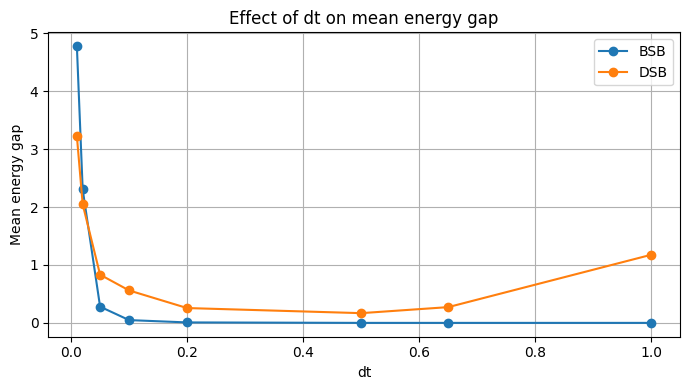

In [11]:
plt.figure(figsize=(7, 4))

for variant in ["BSB", "DSB"]:
    part = summary_dt_sweep[
        summary_dt_sweep["variant"] == variant
    ].sort_values("dt")

    plt.plot(
        part["dt"],
        part["mean_gap"],
        marker="o",
        label=variant,
    )

plt.xlabel("dt")
plt.ylabel("Mean energy gap")
plt.title("Effect of dt on mean energy gap")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("fig_04_03_03_dt_mean_gap.png", dpi=300)
plt.show()

In [12]:
results_dt_sweep_raw.to_csv(
    "results_04_03_03_dt_sweep_raw.csv",
    index=False,
)

summary_dt_sweep.to_csv(
    "summary_04_03_03_dt_sweep.csv",
    index=False,
)

print("Saved dt sweep results.")

Saved dt sweep results.


Лучший общий выбор сейчас - dt = 0.5:

bSB: success_rate = 1.000, mean_gap = 0.000

dSB: success_rate = 0.932, mean_gap = 0.168

При dt=0.65 и dt=1.0 bSB тоже идеален, но dSB хуже. 

Поэтому для следующего эксперимента честнее взять dt=0.5: он хорошо работает для обоих алгоритмов.

При слишком малом dt система за фиксированные 1000 итераций проходит слишком малую эффективную длину эволюции. Поэтому dt=0.01 и dt=0.02 дают низкий success_rate. При увеличении dt динамика быстрее доходит до области устойчивых знаковых состояний, и качество резко улучшается.

# Влияние числа итераций `n_iter`

После анализа шага интегрирования было выбрано рабочее значение `dt = 0.5`, поскольку при нём bSB показал максимальную вероятность успеха, а dSB сохранял достаточно высокое качество.

Теперь фиксируем `dt = 0.5` и исследуем влияние числа итераций `n_iter`.

Число итераций определяет длительность SB-динамики и дискретное расписание параметра накачки. При слишком малом `n_iter` система может не успевать перейти в устойчивую область, соответствующую дискретной конфигурации спинов. При слишком большом `n_iter` качество может улучшаться незначительно, но вычислительное время растёт.

In [13]:
N_ITER_VALUES = [25, 50, 100, 200, 500, 1000, 1500, 2000]

FIXED_DT_FOR_N_ITER = 0.5
FIXED_N_RUNS_FOR_N_ITER = 50

N_ITER_SWEEP_SEED = 888

In [14]:
n_iter_sweep_rows = []

for n_iter in N_ITER_VALUES:
    print(f"n_iter = {n_iter}")

    for item in benchmark_instances:
        instance_id = item["instance_id"]
        J = item["J"]
        h = item["h"]
        E_exact = item["E_exact"]

        for variant in ["BSB", "DSB"]:
            df = run_sb_many(
                J=J,
                h=h,
                variant=variant,
                n_runs=FIXED_N_RUNS_FOR_N_ITER,
                n_iter=n_iter,
                dt=FIXED_DT_FOR_N_ITER,
                seed=N_ITER_SWEEP_SEED + 10_000 * instance_id,
            )

            gaps = df["energy"].values - E_exact

            n_iter_sweep_rows.append({
                "N": BENCHMARK_N,
                "instance_id": instance_id,
                "variant": variant,
                "dt": FIXED_DT_FOR_N_ITER,
                "n_iter": n_iter,
                "n_runs": FIXED_N_RUNS_FOR_N_ITER,
                "E_exact": E_exact,
                "E_best": df["energy"].min(),
                "success_rate": np.mean(np.isclose(df["energy"], E_exact)),
                "mean_gap": np.mean(gaps),
                "median_gap": np.median(gaps),
                "best_gap": np.min(gaps),
                "max_gap": np.max(gaps),
                "mean_runtime_sec": df["runtime_sec"].mean(),
            })

results_n_iter_sweep_raw = pd.DataFrame(n_iter_sweep_rows)

results_n_iter_sweep_raw.head()

n_iter = 25
n_iter = 50
n_iter = 100
n_iter = 200
n_iter = 500
n_iter = 1000
n_iter = 1500
n_iter = 2000


,N,instance_id,variant,dt,n_iter,n_runs,E_exact,E_best,success_rate,mean_gap,median_gap,best_gap,max_gap,mean_runtime_sec
0,16,0,BSB,0.5,25,50,-40.0,-40.0,0.42,2.52,2.0,0.0,12.0,0.000832
1,16,0,DSB,0.5,25,50,-40.0,-40.0,0.36,1.76,2.0,0.0,8.0,0.000796
2,16,1,BSB,0.5,25,50,-38.0,-38.0,0.08,5.88,4.0,0.0,22.0,0.000754
3,16,1,DSB,0.5,25,50,-38.0,-38.0,0.10,3.76,3.0,0.0,10.0,0.000780
4,16,2,BSB,0.5,25,50,-40.0,-40.0,0.02,4.56,4.0,0.0,24.0,0.000826


In [15]:
summary_n_iter_sweep = (
    results_n_iter_sweep_raw
    .groupby(["n_iter", "variant"], as_index=False)
    .agg(
        mean_success_rate=("success_rate", "mean"),
        median_success_rate=("success_rate", "median"),
        mean_gap=("mean_gap", "mean"),
        median_gap=("median_gap", "mean"),
        mean_best_gap=("best_gap", "mean"),
        mean_runtime_sec=("mean_runtime_sec", "mean"),
        n_instances=("instance_id", "nunique"),
    )
)

summary_n_iter_sweep["mean_runtime_ms"] = (
    1000 * summary_n_iter_sweep["mean_runtime_sec"]
)

summary_n_iter_sweep = summary_n_iter_sweep.drop(columns=["mean_runtime_sec"])

summary_n_iter_sweep

,n_iter,variant,mean_success_rate,median_success_rate,mean_gap,median_gap,mean_best_gap,n_instances,mean_runtime_ms
0,25,BSB,0.208,0.08,4.528,3.2,0.0,5,0.792726
1,25,DSB,0.348,0.32,2.664,1.8,0.0,5,0.791612
2,50,BSB,0.616,0.72,1.256,0.4,0.0,5,1.555347
3,50,DSB,0.608,0.52,1.400,0.8,0.0,5,1.550289
4,100,BSB,0.828,0.96,0.400,0.2,0.0,5,2.972279
5,100,DSB,0.708,0.60,0.848,0.2,0.0,5,3.119031
6,200,BSB,0.952,1.00,0.096,0.0,0.0,5,5.962214
7,200,DSB,0.800,0.70,0.480,0.0,0.0,5,6.111278
8,500,BSB,1.000,1.00,0.000,0.0,0.0,5,14.722697
9,500,DSB,0.904,0.94,0.200,0.0,0.0,5,15.199034


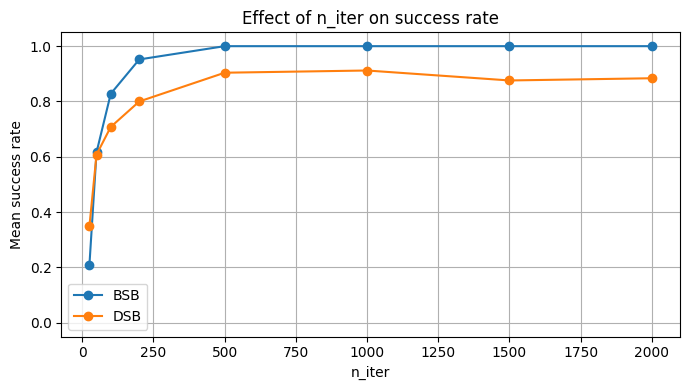

In [16]:
plt.figure(figsize=(7, 4))

for variant in ["BSB", "DSB"]:
    part = summary_n_iter_sweep[
        summary_n_iter_sweep["variant"] == variant
    ].sort_values("n_iter")

    plt.plot(
        part["n_iter"],
        part["mean_success_rate"],
        marker="o",
        label=variant,
    )

plt.xlabel("n_iter")
plt.ylabel("Mean success rate")
plt.title("Effect of n_iter on success rate")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("fig_04_03_03_n_iter_success_rate.png", dpi=300)
plt.show()

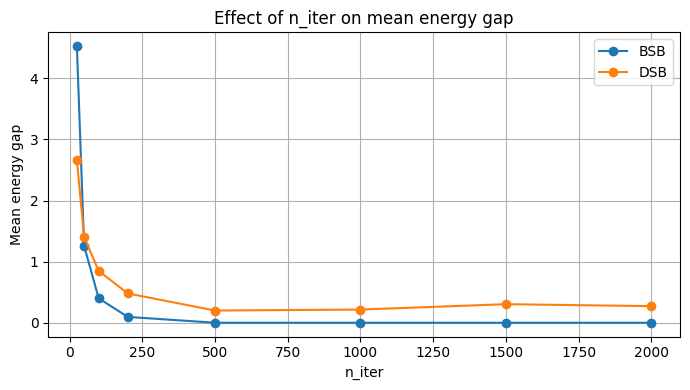

In [17]:
plt.figure(figsize=(7, 4))

for variant in ["BSB", "DSB"]:
    part = summary_n_iter_sweep[
        summary_n_iter_sweep["variant"] == variant
    ].sort_values("n_iter")

    plt.plot(
        part["n_iter"],
        part["mean_gap"],
        marker="o",
        label=variant,
    )

plt.xlabel("n_iter")
plt.ylabel("Mean energy gap")
plt.title("Effect of n_iter on mean energy gap")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("fig_04_03_03_n_iter_mean_gap.png", dpi=300)
plt.show()

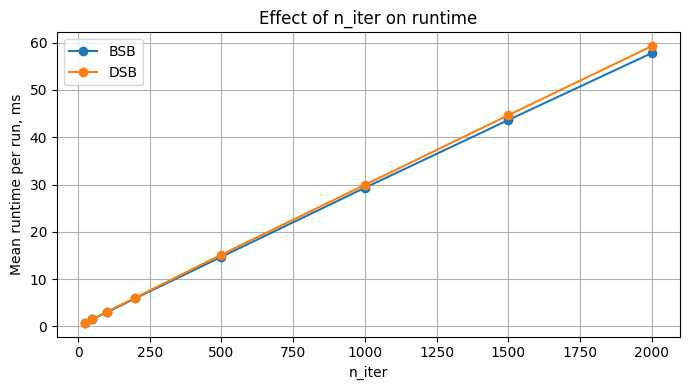

In [18]:
plt.figure(figsize=(7, 4))

for variant in ["BSB", "DSB"]:
    part = summary_n_iter_sweep[
        summary_n_iter_sweep["variant"] == variant
    ].sort_values("n_iter")

    plt.plot(
        part["n_iter"],
        part["mean_runtime_ms"],
        marker="o",
        label=variant,
    )

plt.xlabel("n_iter")
plt.ylabel("Mean runtime per run, ms")
plt.title("Effect of n_iter on runtime")
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("fig_04_03_03_n_iter_runtime.png", dpi=300)
plt.show()

In [19]:
results_n_iter_sweep_raw.to_csv(
    "results_04_03_03_n_iter_sweep_raw.csv",
    index=False,
)

summary_n_iter_sweep.to_csv(
    "summary_04_03_03_n_iter_sweep.csv",
    index=False,
)

print("Saved n_iter sweep results.")

Saved n_iter sweep results.


In [20]:
dt = 0.5
n_iter = 500

# Влияние числа независимых запусков `n_runs`

SB является эвристическим алгоритмом: один запуск может завершиться как в глобальном минимуме, так и в локальном минимуме. Поэтому на практике используется multi-start схема: алгоритм запускается несколько раз из разных случайных начальных условий, после чего выбирается лучшее найденное решение.

Если вероятность успеха одного запуска равна $p$, то вероятность найти глобальный минимум хотя бы один раз за $R$ независимых запусков равна

$$
P_{\mathrm{any}}(R) = 1 - (1-p)^R.
$$

В этом эксперименте фиксируем:

- `dt = 0.5`;
- `n_iter = 500`;

и оцениваем, как растёт вероятность успеха при увеличении `n_runs`.

In [21]:
N_RUNS_VALUES = [1, 2, 5, 10, 20, 50, 100, 200]

FIXED_DT_FOR_N_RUNS = 0.5
FIXED_N_ITER_FOR_N_RUNS = 500

MAX_RUNS_FOR_ESTIMATION = 200
N_RUNS_SWEEP_SEED = 999

In [22]:
n_runs_base_rows = []

for item in benchmark_instances:
    instance_id = item["instance_id"]
    J = item["J"]
    h = item["h"]
    E_exact = item["E_exact"]

    print(f"instance_id = {instance_id}")

    for variant in ["BSB", "DSB"]:
        print(f"  variant = {variant}")

        df = run_sb_many(
            J=J,
            h=h,
            variant=variant,
            n_runs=MAX_RUNS_FOR_ESTIMATION,
            n_iter=FIXED_N_ITER_FOR_N_RUNS,
            dt=FIXED_DT_FOR_N_RUNS,
            seed=N_RUNS_SWEEP_SEED + 10_000 * instance_id,
        )

        df["N"] = BENCHMARK_N
        df["instance_id"] = instance_id
        df["dt"] = FIXED_DT_FOR_N_RUNS
        df["n_iter"] = FIXED_N_ITER_FOR_N_RUNS
        df["E_exact"] = E_exact
        df["gap"] = df["energy"] - E_exact
        df["is_success"] = np.isclose(df["energy"], E_exact)

        n_runs_base_rows.append(df)

results_n_runs_base = pd.concat(
    n_runs_base_rows,
    ignore_index=True,
)

results_n_runs_base.head()

instance_id = 0
  variant = BSB
  variant = DSB
instance_id = 1
  variant = BSB
  variant = DSB
instance_id = 2
  variant = BSB
  variant = DSB
instance_id = 3
  variant = BSB
  variant = DSB
instance_id = 4
  variant = BSB
  variant = DSB


,variant,run,seed,energy,state,runtime_sec,N,instance_id,dt,n_iter,E_exact,gap,is_success
0,BSB,0,999,-40.0,"(-1, 1, 1, 1, -1, 1, 1, 1, -1, -1, -1, 1, 1, -...",0.017289,16,0,0.5,500,-40.0,0.0,True
1,BSB,1,1000,-40.0,"(1, -1, -1, -1, 1, -1, -1, -1, 1, 1, 1, -1, -1...",0.017469,16,0,0.5,500,-40.0,0.0,True
2,BSB,2,1001,-40.0,"(-1, 1, 1, -1, -1, -1, 1, 1, -1, -1, -1, 1, 1,...",0.014768,16,0,0.5,500,-40.0,0.0,True
3,BSB,3,1002,-40.0,"(-1, 1, 1, 1, -1, 1, 1, 1, -1, -1, -1, 1, 1, -...",0.014410,16,0,0.5,500,-40.0,0.0,True
4,BSB,4,1003,-40.0,"(-1, 1, 1, -1, -1, -1, 1, 1, -1, -1, -1, 1, 1,...",0.021533,16,0,0.5,500,-40.0,0.0,True


In [23]:
summary_single_run = (
    results_n_runs_base
    .groupby(["instance_id", "variant"], as_index=False)
    .agg(
        p_single=("is_success", "mean"),
        mean_gap_single=("gap", "mean"),
        median_gap_single=("gap", "median"),
        best_gap_single=("gap", "min"),
        mean_runtime_sec=("runtime_sec", "mean"),
    )
)

summary_single_run

,instance_id,variant,p_single,mean_gap_single,median_gap_single,best_gap_single,mean_runtime_sec
0,0,BSB,1.000,0.00,0.0,0.0,0.014990
1,0,DSB,0.665,0.68,0.0,0.0,0.015109
2,1,BSB,1.000,0.00,0.0,0.0,0.014566
3,1,DSB,0.930,0.14,0.0,0.0,0.014886
4,2,BSB,1.000,0.00,0.0,0.0,0.014569
5,2,DSB,1.000,0.00,0.0,0.0,0.015160
6,3,BSB,1.000,0.00,0.0,0.0,0.014700
7,3,DSB,0.930,0.22,0.0,0.0,0.014850
8,4,BSB,1.000,0.00,0.0,0.0,0.014336
9,4,DSB,0.970,0.12,0.0,0.0,0.015328


In [24]:
n_runs_sweep_rows = []

for _, row in summary_single_run.iterrows():
    instance_id = row["instance_id"]
    variant = row["variant"]
    p_single = row["p_single"]

    for R in N_RUNS_VALUES:
        p_any = 1.0 - (1.0 - p_single) ** R

        n_runs_sweep_rows.append({
            "N": BENCHMARK_N,
            "instance_id": instance_id,
            "variant": variant,
            "n_runs": R,
            "dt": FIXED_DT_FOR_N_RUNS,
            "n_iter": FIXED_N_ITER_FOR_N_RUNS,
            "p_single": p_single,
            "p_any_success": p_any,
        })

results_n_runs_sweep_raw = pd.DataFrame(n_runs_sweep_rows)

results_n_runs_sweep_raw.head()

,N,instance_id,variant,n_runs,dt,n_iter,p_single,p_any_success
0,16,0,BSB,1,0.5,500,1.0,1.0
1,16,0,BSB,2,0.5,500,1.0,1.0
2,16,0,BSB,5,0.5,500,1.0,1.0
3,16,0,BSB,10,0.5,500,1.0,1.0
4,16,0,BSB,20,0.5,500,1.0,1.0


In [25]:
summary_n_runs_sweep = (
    results_n_runs_sweep_raw
    .groupby(["n_runs", "variant"], as_index=False)
    .agg(
        mean_p_single=("p_single", "mean"),
        mean_p_any_success=("p_any_success", "mean"),
        median_p_any_success=("p_any_success", "median"),
        min_p_any_success=("p_any_success", "min"),
        max_p_any_success=("p_any_success", "max"),
        n_instances=("instance_id", "nunique"),
    )
)

summary_n_runs_sweep

,n_runs,variant,mean_p_single,mean_p_any_success,median_p_any_success,min_p_any_success,max_p_any_success,n_instances
0,1,BSB,1.000,1.000000,1.000000,1.000000,1.0,5
1,1,DSB,0.899,0.899000,0.930000,0.665000,1.0,5
2,2,BSB,1.000,1.000000,1.000000,1.000000,1.0,5
3,2,DSB,0.899,0.975415,0.995100,0.887775,1.0,5
4,5,BSB,1.000,1.000000,1.000000,1.000000,1.0,5
5,5,DSB,0.899,0.999155,0.999998,0.995781,1.0,5
6,10,BSB,1.000,1.000000,1.000000,1.000000,1.0,5
7,10,DSB,0.899,0.999996,1.000000,0.999982,1.0,5
8,20,BSB,1.000,1.000000,1.000000,1.000000,1.0,5
9,20,DSB,0.899,1.000000,1.000000,1.000000,1.0,5


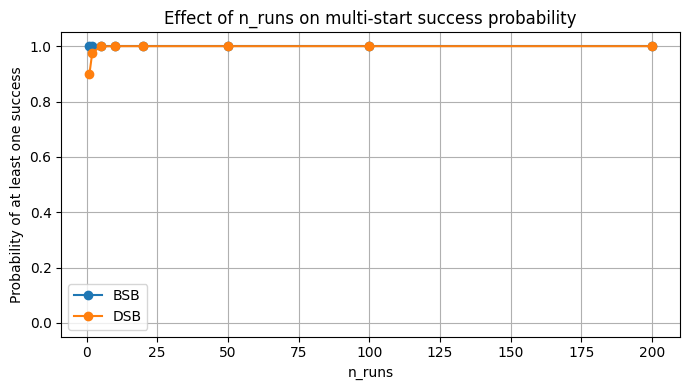

In [26]:
plt.figure(figsize=(7, 4))

for variant in ["BSB", "DSB"]:
    part = summary_n_runs_sweep[
        summary_n_runs_sweep["variant"] == variant
    ].sort_values("n_runs")

    plt.plot(
        part["n_runs"],
        part["mean_p_any_success"],
        marker="o",
        label=variant,
    )

plt.xlabel("n_runs")
plt.ylabel("Probability of at least one success")
plt.title("Effect of n_runs on multi-start success probability")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("fig_04_03_03_n_runs_success_probability.png", dpi=300)
plt.show()

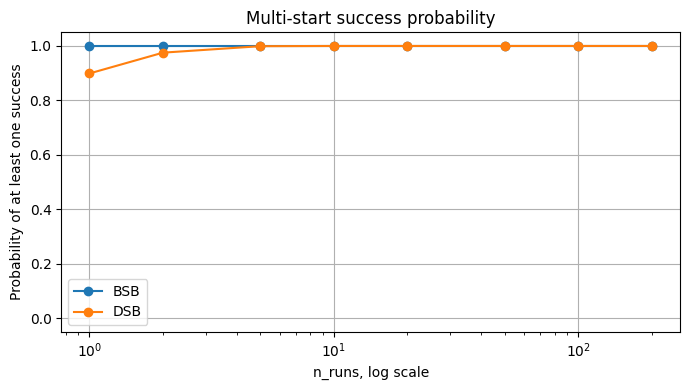

In [27]:
plt.figure(figsize=(7, 4))

for variant in ["BSB", "DSB"]:
    part = summary_n_runs_sweep[
        summary_n_runs_sweep["variant"] == variant
    ].sort_values("n_runs")

    plt.plot(
        part["n_runs"],
        part["mean_p_any_success"],
        marker="o",
        label=variant,
    )

plt.xscale("log")
plt.xlabel("n_runs, log scale")
plt.ylabel("Probability of at least one success")
plt.title("Multi-start success probability")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("fig_04_03_03_n_runs_success_probability_logx.png", dpi=300)
plt.show()

In [28]:
runtime_single = (
    results_n_runs_base
    .groupby(["variant"], as_index=False)
    .agg(mean_runtime_sec=("runtime_sec", "mean"))
)

runtime_single

,variant,mean_runtime_sec
0,BSB,0.014632
1,DSB,0.015067


In [29]:
summary_n_runs_runtime = summary_n_runs_sweep.merge(
    runtime_single,
    on="variant",
    how="left",
)

summary_n_runs_runtime["expected_total_runtime_ms"] = (
    1000
    * summary_n_runs_runtime["n_runs"]
    * summary_n_runs_runtime["mean_runtime_sec"]
)

summary_n_runs_runtime = summary_n_runs_runtime.drop(
    columns=["mean_runtime_sec"]
)

summary_n_runs_runtime

,n_runs,variant,mean_p_single,mean_p_any_success,median_p_any_success,min_p_any_success,max_p_any_success,n_instances,expected_total_runtime_ms
0,1,BSB,1.000,1.000000,1.000000,1.000000,1.0,5,14.632193
1,1,DSB,0.899,0.899000,0.930000,0.665000,1.0,5,15.066685
2,2,BSB,1.000,1.000000,1.000000,1.000000,1.0,5,29.264385
3,2,DSB,0.899,0.975415,0.995100,0.887775,1.0,5,30.133370
4,5,BSB,1.000,1.000000,1.000000,1.000000,1.0,5,73.160963
5,5,DSB,0.899,0.999155,0.999998,0.995781,1.0,5,75.333425
6,10,BSB,1.000,1.000000,1.000000,1.000000,1.0,5,146.321926
7,10,DSB,0.899,0.999996,1.000000,0.999982,1.0,5,150.666850
8,20,BSB,1.000,1.000000,1.000000,1.000000,1.0,5,292.643852
9,20,DSB,0.899,1.000000,1.000000,1.000000,1.0,5,301.333700


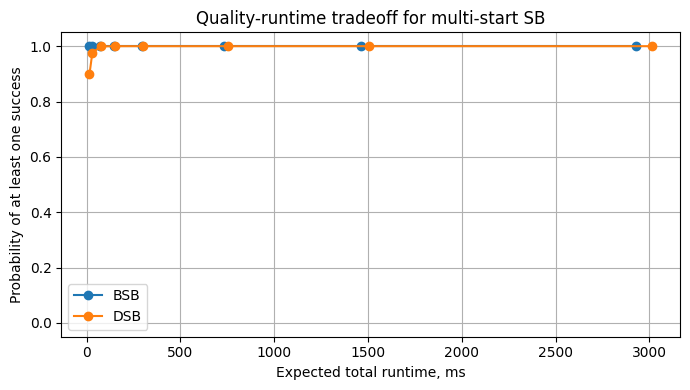

In [30]:
plt.figure(figsize=(7, 4))

for variant in ["BSB", "DSB"]:
    part = summary_n_runs_runtime[
        summary_n_runs_runtime["variant"] == variant
    ].sort_values("expected_total_runtime_ms")

    plt.plot(
        part["expected_total_runtime_ms"],
        part["mean_p_any_success"],
        marker="o",
        label=variant,
    )

plt.xlabel("Expected total runtime, ms")
plt.ylabel("Probability of at least one success")
plt.title("Quality-runtime tradeoff for multi-start SB")
plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.savefig("fig_04_03_03_quality_runtime_tradeoff.png", dpi=300)
plt.show()

In [31]:
results_n_runs_base.to_csv(
    "results_04_03_03_n_runs_base.csv",
    index=False,
)

results_n_runs_sweep_raw.to_csv(
    "results_04_03_03_n_runs_sweep_raw.csv",
    index=False,
)

summary_n_runs_sweep.to_csv(
    "summary_04_03_03_n_runs_sweep.csv",
    index=False,
)

summary_n_runs_runtime.to_csv(
    "summary_04_03_03_n_runs_runtime.csv",
    index=False,
)

print("Saved n_runs sweep results.")

Saved n_runs sweep results.


## Вывод по влиянию n_runs

При фиксированных параметрах `dt = 0.5` и `n_iter = 500` bSB на выбранном benchmark-наборе достиг вероятности успеха одного запуска, равной единице. Это означает, что для данного класса задач увеличение `n_runs` не улучшает качество bSB, а только линейно увеличивает время вычислений.

Для dSB вероятность успеха одного запуска составила около 0.899. Однако multi-start схема быстро повышает вероятность нахождения глобального минимума: уже при `n_runs = 5` средняя вероятность хотя бы одного успешного запуска превышает 0.999, а при `n_runs = 10` практически равна единице.

С учётом компромисса между качеством и временем дальнейшие эксперименты целесообразно проводить с параметрами `dt = 0.5`, `n_iter = 500`, `n_runs = 10`. Такой выбор сохраняет высокую надёжность для обоих вариантов SB и не приводит к чрезмерному росту времени вычислений.

In [32]:
dt = 0.5
n_iter = 500
n_runs = 10

In [33]:
selected_sb_params = pd.DataFrame([
    {
        "parameter": "dt",
        "selected_value": 0.5,
        "reason": "Лучший компромисс по success_rate для bSB и dSB в dt-sweep.",
    },
    {
        "parameter": "n_iter",
        "selected_value": 500,
        "reason": "bSB уже достигает success_rate=1.0; дальнейший рост n_iter почти не улучшает качество, но увеличивает время.",
    },
    {
        "parameter": "n_runs",
        "selected_value": 10,
        "reason": "Для dSB multi-start вероятность успеха становится практически равной 1; для bSB достаточно и меньшего числа запусков.",
    },
])

selected_sb_params

,parameter,selected_value,reason
0,dt,0.5,Лучший компромисс по success_rate для bSB и dS...
1,n_iter,500.0,bSB уже достигает success_rate=1.0; дальнейший...
2,n_runs,10.0,Для dSB multi-start вероятность успеха станови...


In [34]:
selected_sb_params.to_csv(
    "selected_sb_parameters_after_04_03_03.csv",
    index=False,
)

print("Saved: selected_sb_parameters_after_04_03_03.csv")

Saved: selected_sb_parameters_after_04_03_03.csv


# Итоговые выводы по чувствительности SB к параметрам

В данной тетрадке было исследовано влияние трёх основных параметров SB-динамики: шага интегрирования `dt`, числа итераций `n_iter` и числа независимых запусков `n_runs`.

### Влияние `dt`

При фиксированных `n_iter = 1000` и `n_runs = 50` было показано, что слишком малые значения `dt` приводят к низкой вероятности нахождения глобального минимума. Это связано с тем, что за фиксированное число итераций система проходит слишком малую эффективную длину эволюции. При увеличении `dt` качество решений существенно возрастает.

На выбранном benchmark-наборе наилучший компромисс был получен при `dt = 0.5`: bSB достиг `success_rate = 1.0`, а dSB показал высокую, хотя не идеальную, вероятность успеха.

### Влияние `n_iter`

При фиксированном `dt = 0.5` увеличение числа итераций улучшает качество решений до определённого уровня. Для bSB уже при `n_iter = 500` была достигнута вероятность успеха, равная единице. Дальнейшее увеличение `n_iter` не улучшало качество bSB, но почти линейно увеличивало время вычислений.

Для dSB качество также улучшалось при росте `n_iter`, однако не становилось строго монотонным и не достигало идеального значения на всём benchmark-наборе. Поэтому выбор `n_iter = 500` является разумным компромиссом между качеством и временем.

### Влияние `n_runs`

SB является эвристическим методом, поэтому практическая стратегия состоит в нескольких независимых запусках с последующим выбором лучшего найденного решения. Для bSB при `dt = 0.5` и `n_iter = 500` вероятность успеха одного запуска на выбранном benchmark-наборе оказалась равной единице. Для dSB вероятность успеха одного запуска была ниже, но multi-start схема быстро повышала вероятность нахождения оптимума.

При `n_runs = 5` вероятность хотя бы одного успешного запуска dSB уже превышала 0.999, а при `n_runs = 10` становилась практически равной единице. Поэтому для дальнейших экспериментов выбран набор параметров:

$$
dt = 0.5, \qquad n_{\mathrm{iter}} = 500, \qquad n_{\mathrm{runs}} = 10.
$$

Такой выбор обеспечивает высокую надёжность для обоих вариантов SB и при этом не приводит к чрезмерному росту времени вычислений.